# Data Science Job Market Analysis

**Name:** Mayenmein Terence Sama Aloah Jr  
**Date:** 01/11/2025  
**Dataset:** Data Science Job Market Trends


## Project Overview
This notebook provides a comprehensive analysis of data science job market trends, skill requirements, and career pathways using data-driven approaches. The analysis focuses on identifying key skills, emerging trends, and personalized recommendations for career development.

## 1. Initial Setup and Configuration

### 1.1 Import Required Libraries
Import all necessary packages and configure the environment for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import warnings
from tqdm.auto import tqdm
import sys
warnings.filterwarnings('ignore')

import plotly.io as pio

# Set up notebook display
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
%matplotlib inline
pio.renderers.default = 'notebook'  # For Plotly in notebook

# Set up plotting style
plt.style.use('default')
sns.set_palette("viridis")

In [ ]:
sys.path.append('..')
from src.main import DataScienceJobsAnalyzer
from src.core.data_processor import DataProcessor
from src.analysis.skill_analyzer import SkillAnalyzer
from src.analysis.trend_analyzer import TrendAnalyzer
from src.analysis.seniority_analyzer import SeniorityAnalyzer
from src.analysis.role_analyzer import RoleAnalyzer
from src.analysis.ecosystem_analyzer import EcosystemAnalyzer
# Initialize the analyzer

from src.visualizations.market_analysis_plot import MarketAnalysisPlot
from src.visualizations.role_analysis_plot import RoleAnalysisPlot
from src.visualizations.trends_plot import TrendsAnalysisPlot

In [ ]:
data_dir="../data"
data_processor = DataProcessor(data_dir)
skill_analyzer = SkillAnalyzer(data_dir)
trend_analyzer = TrendAnalyzer(data_dir)
seniority_analyzer = SeniorityAnalyzer(data_dir)
role_analyzer = RoleAnalyzer(data_dir)
ecosystem_analyzer = EcosystemAnalyzer(data_dir)

### 1.2 Load and Prepare Data
Load the pre-processed dataset containing job market information.

In [3]:
# Load and clean the data
df = analyzer.load_cleaned_data()

df.info()


INFO:src.analyze_jobs:✅ Loaded 18088 cleaned records


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18088 entries, 0 to 18087
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 18088 non-null  object 
 1   company                 18088 non-null  object 
 2   cleaned_title_category  18088 non-null  object 
 3   seniority_level         18088 non-null  object 
 4   skills                  18088 non-null  object 
 5   date                    18088 non-null  object 
 6   salary_category         18088 non-null  object 
 7   avg_salary_usd          6978 non-null   float64
 8   job_type                18088 non-null  object 
 9   work_mode               18088 non-null  object 
 10  skills_count            18088 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 1.5+ MB


In [4]:
pivot_df = analyzer.create_skill_pivot(df)

print(f"✅ Successfully loaded {len(df):,} job records")
print(f"📊 Created skill pivot with {len(pivot_df):,} skill mentions")
print(f"🎯 Analyzing {pivot_df['skill'].nunique():,} unique skills")

# Display basic dataset info
print("\n📈 Dataset Overview:")
print(f"   • Time period: {pivot_df['date'].min()} to {pivot_df['date'].max()}")
print(f"   • Countries: {pivot_df['country'].nunique()}")
print(f"   • Companies: {pivot_df['company'].nunique()}")
print(f"   • Job roles: {pivot_df['cleaned_title_category'].nunique()}")
print(f"   • Seniority levels: {pivot_df['seniority_level'].nunique()}")



✅ Successfully loaded 18,088 job records
📊 Created skill pivot with 221,951 skill mentions
🎯 Analyzing 327 unique skills

📈 Dataset Overview:
   • Time period: 2023.0_10.0 to 2025.0_9.0
   • Countries: 115
   • Companies: 2418
   • Job roles: 12
   • Seniority levels: 8


## 2. Market Overview Analysis
### 2.1 Overall Skill Frequency Analysis

🏆 TOP 5 MOST IN-DEMAND SKILLS


<Figure size 1400x800 with 0 Axes>

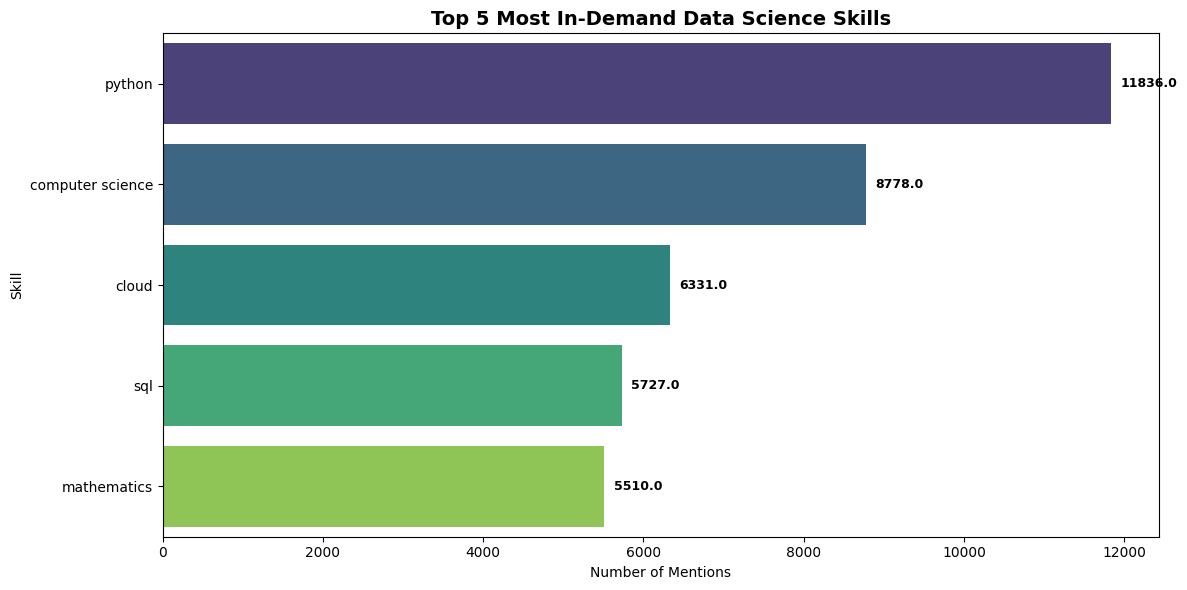

,skill,mentions,prevalence,total_jobs
0,python,"11,836",65.6%,18029
1,computer science,"8,778",48.7%,18029
2,cloud,"6,331",35.1%,18029
3,sql,"5,727",31.8%,18029
4,mathematics,"5,510",30.6%,18029


In [5]:
# Analyze top skills across the entire market
top_skills = analyzer.analyze_skill_frequency(pivot_df, top_n=5)

print("🏆 TOP 5 MOST IN-DEMAND SKILLS")
print("="*50)

plt.figure(figsize=(14, 8))
analyzer.plot_skills_bar(top_skills, column='skill', top_n=5, 
                        title='Top 5 Most In-Demand Data Science Skills')

# Display detailed table
display(top_skills.head(5).style.background_gradient(cmap='Blues', subset=['prevalence'])
       .format({'prevalence': '{:.1f}%', 'mentions': '{:,}'})
       .set_caption('Top 5 Skills by Prevalence'))

## 3. Seniority-Level Analysis
### 3.1 Skills by Seniority Level

👨‍💼 SKILL DISTRIBUTION BY SENIORITY LEVEL


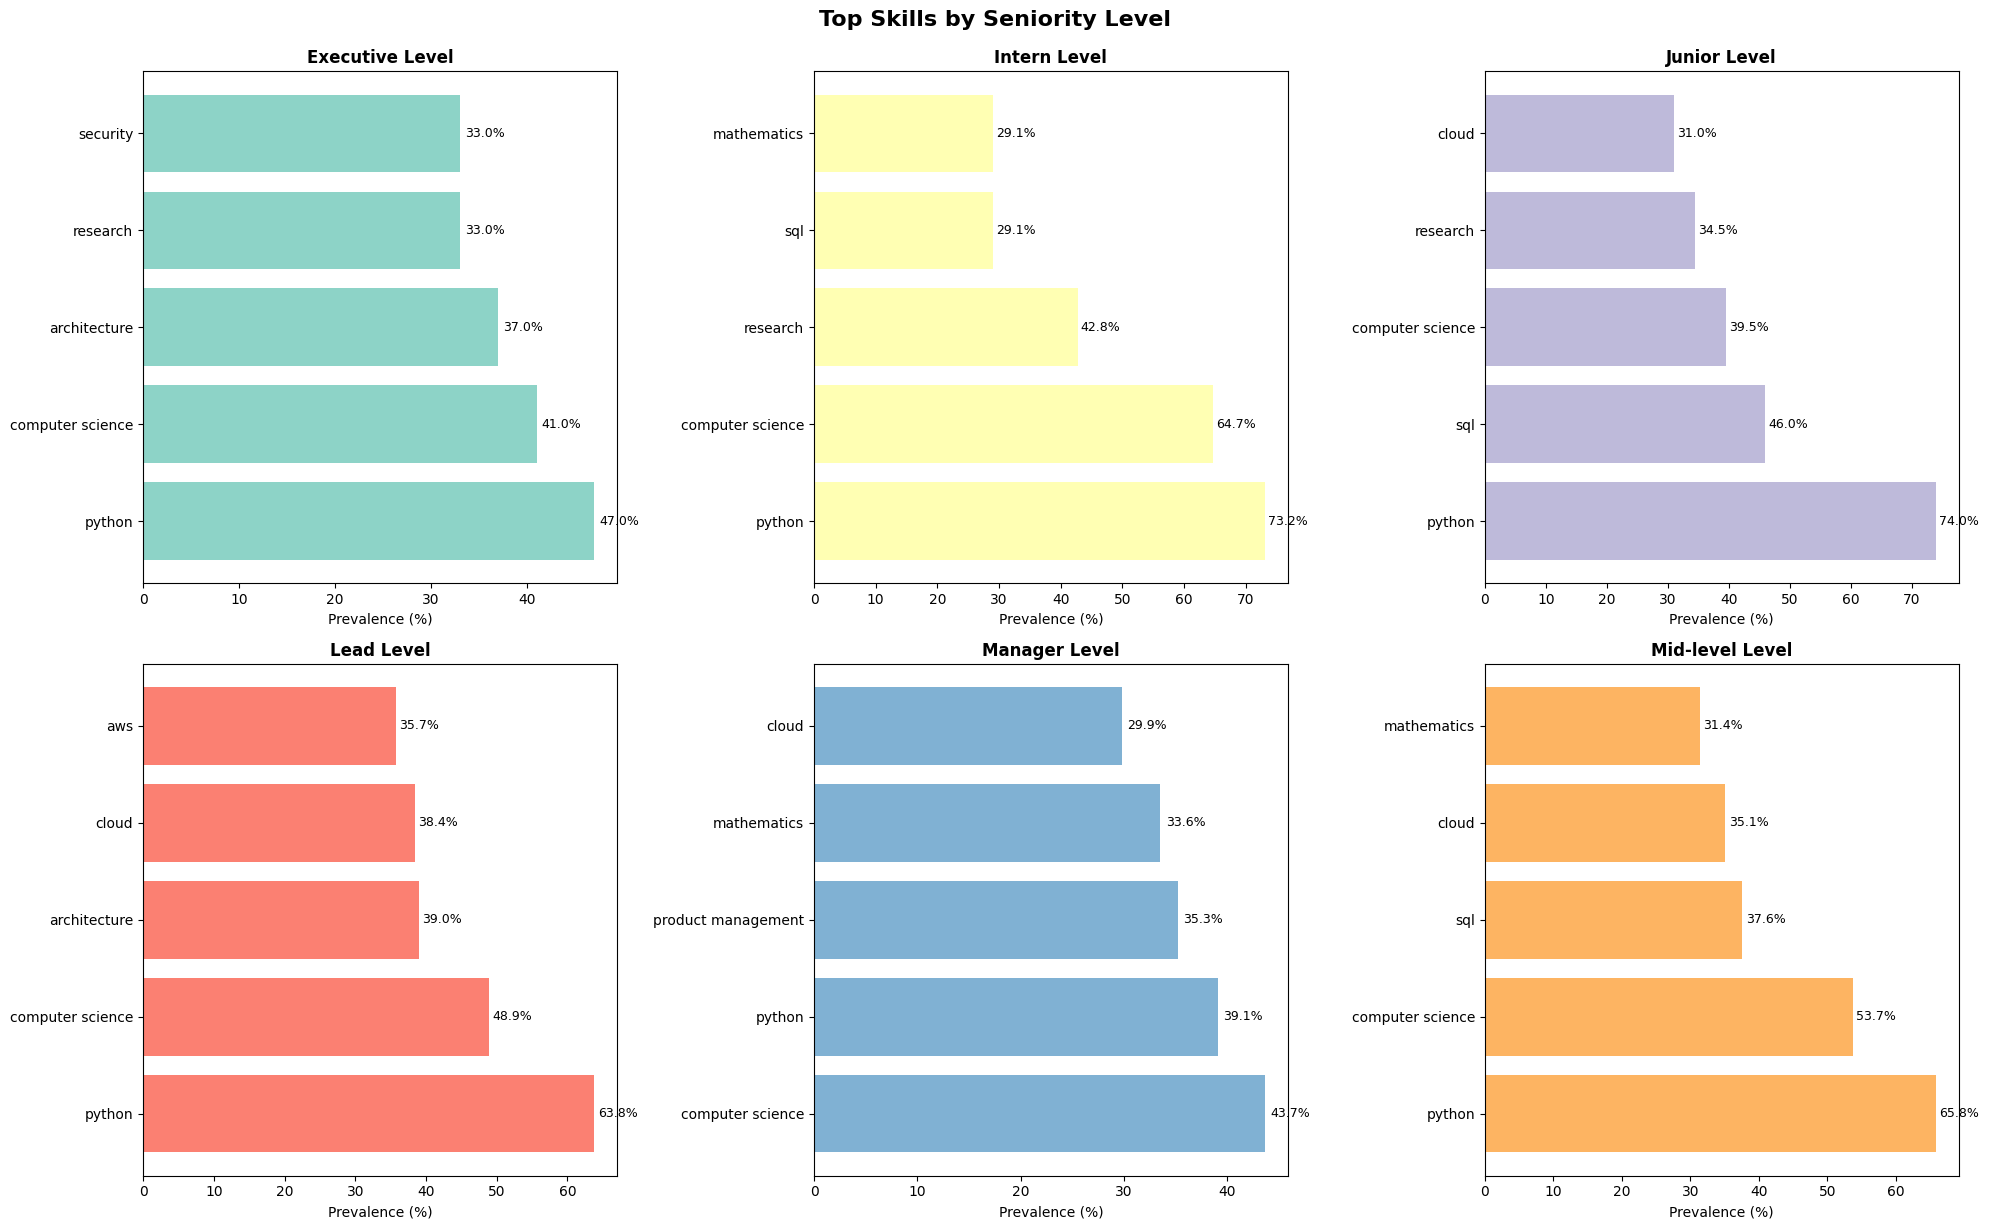

In [6]:
# Analyze skills across different seniority levels
seniority_skills = analyzer.analyze_skills_by_seniority(pivot_df, top_n=5)

print("👨‍💼 SKILL DISTRIBUTION BY SENIORITY LEVEL")
print("="*55)

# Create visualization for each seniority level
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (level, skills_df) in enumerate(seniority_skills.items()):
    if idx < 6:  # Limit to first 6 seniority levels
        ax = axes[idx]
        top_skills = skills_df.head(5)
        
        ax.barh(top_skills['skill'], top_skills['prevalence'], color=analyzer.colors[idx])
        ax.set_title(f'{level} Level', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(top_skills['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Seniority Level', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 3.2 Seniority-Specific Skill Patterns

🎯 ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS


INFO:src.analyze_jobs:🎯 Identifying seniority-specific skill patterns...
Analyzing seniority patterns: 100%|██████████| 6/6 [00:02<00:00,  2.45it/s]
INFO:src.analyze_jobs:
INFO:src.analyze_jobs:🎯 SENIORITY-SPECIFIC SKILL PATTERNS INSIGHTS
INFO:src.analyze_jobs:======================================================================
INFO:src.analyze_jobs:
📋 JUNIOR LEVEL:
INFO:src.analyze_jobs:   • Total jobs: 200
INFO:src.analyze_jobs:   • Unique skills: 205
INFO:src.analyze_jobs:   • Skill concentration: 0.306
INFO:src.analyze_jobs:   • Top skills: python (74.0%), sql (46.0%), computer science (39.5%)
INFO:src.analyze_jobs:   • Level-specific: No strongly specific skills identified
INFO:src.analyze_jobs:
📋 MID-LEVEL LEVEL:
INFO:src.analyze_jobs:   • Total jobs: 322
INFO:src.analyze_jobs:   • Unique skills: 223
INFO:src.analyze_jobs:   • Skill concentration: 0.309
INFO:src.analyze_jobs:   • Top skills: python (65.8%), computer science (53.7%), sql (37.6%)
INFO:src.analyze_jobs:   • Level-

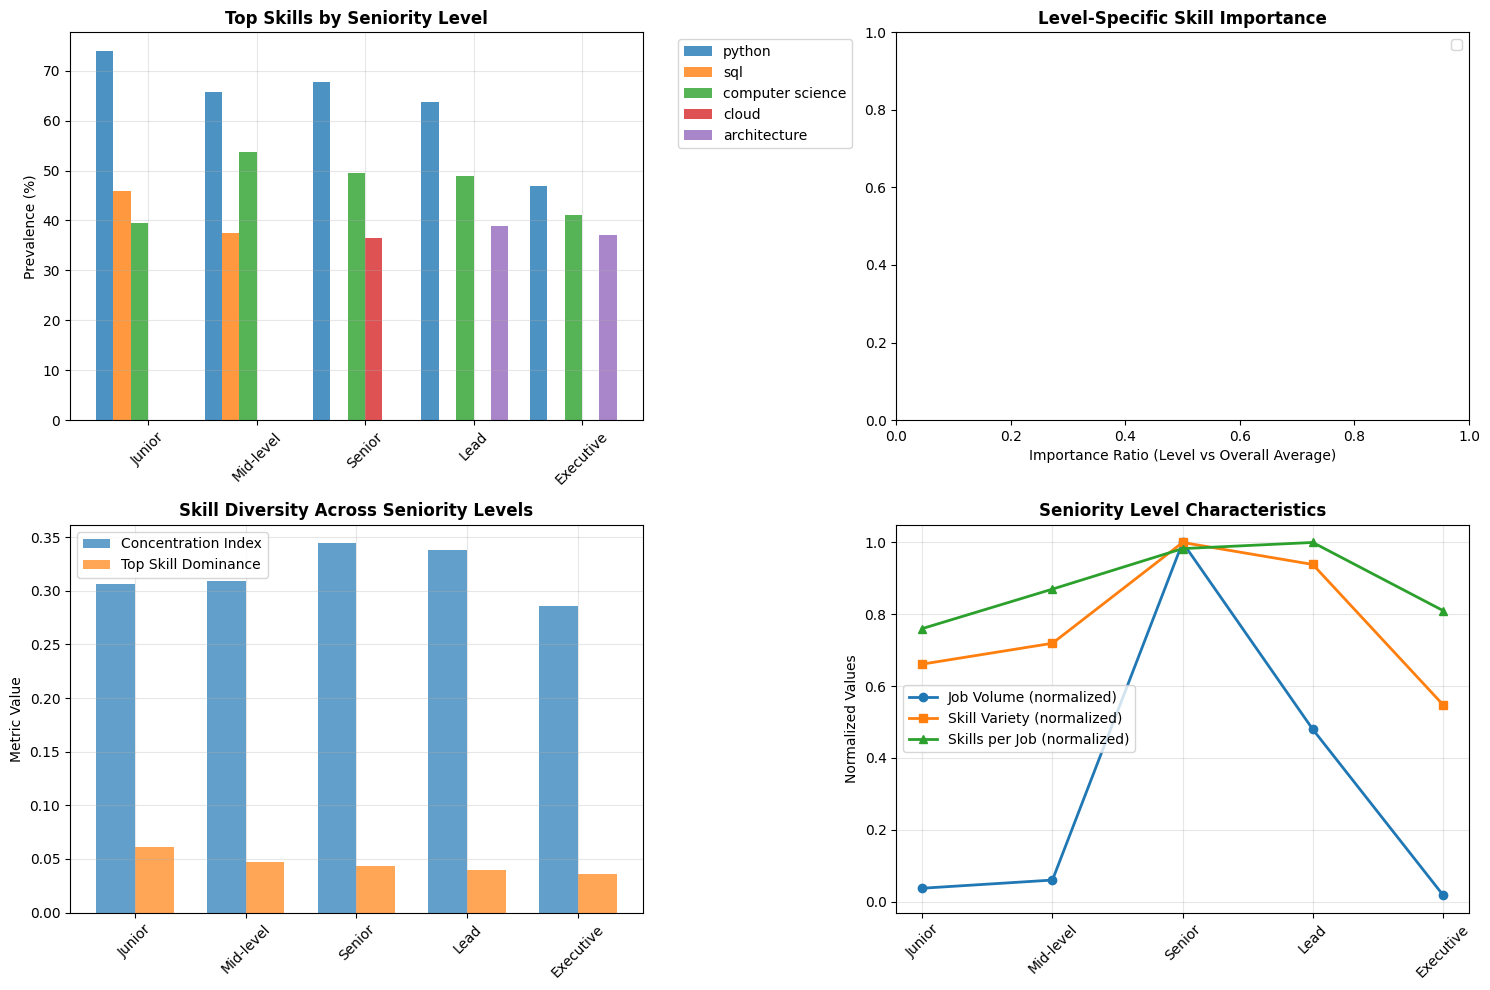

In [7]:
# Identify seniority-specific patterns
print("🎯 ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS")
print("="*55)

# Get progression data for key skills
key_skills = ['Python', 'SQL', 'Machine Learning', 'AWS', 'Tableau', 'Spark']
progression_data = analyzer.analyze_skill_progression_data(pivot_df, key_skills)

# Analyze patterns
seniority_patterns = analyzer.analyze_seniority_specific_patterns(pivot_df, progression_data)

# Create visualization
analyzer.plot_seniority_patterns(seniority_patterns)

### 3.3 Skill Progression Across Career Levels

In [8]:
print("📈 SKILL PROGRESSION ACROSS CAREER LEVELS")
print("="*50)

# Plot organized progression view
analyzer.plot_skill_progression_organized(progression_data)

# Additional simple view for key technical skills
technical_skills = ['Python', 'Machine Learning', 'Spark', 'AWS', 'TensorFlow', 'Kubernetes']
tech_progression = analyzer.analyze_skill_progression_data(pivot_df, technical_skills)

print("\n🔧 Technical Skill Progression:")
analyzer.plot_skill_progression_simple(tech_progression, technical_skills)

📈 SKILL PROGRESSION ACROSS CAREER LEVELS



🔧 Technical Skill Progression:


## 4. Role-Based Analysis
### 4.1 Skills by Job Role 

🎭 SKILL PROFILES BY JOB ROLE


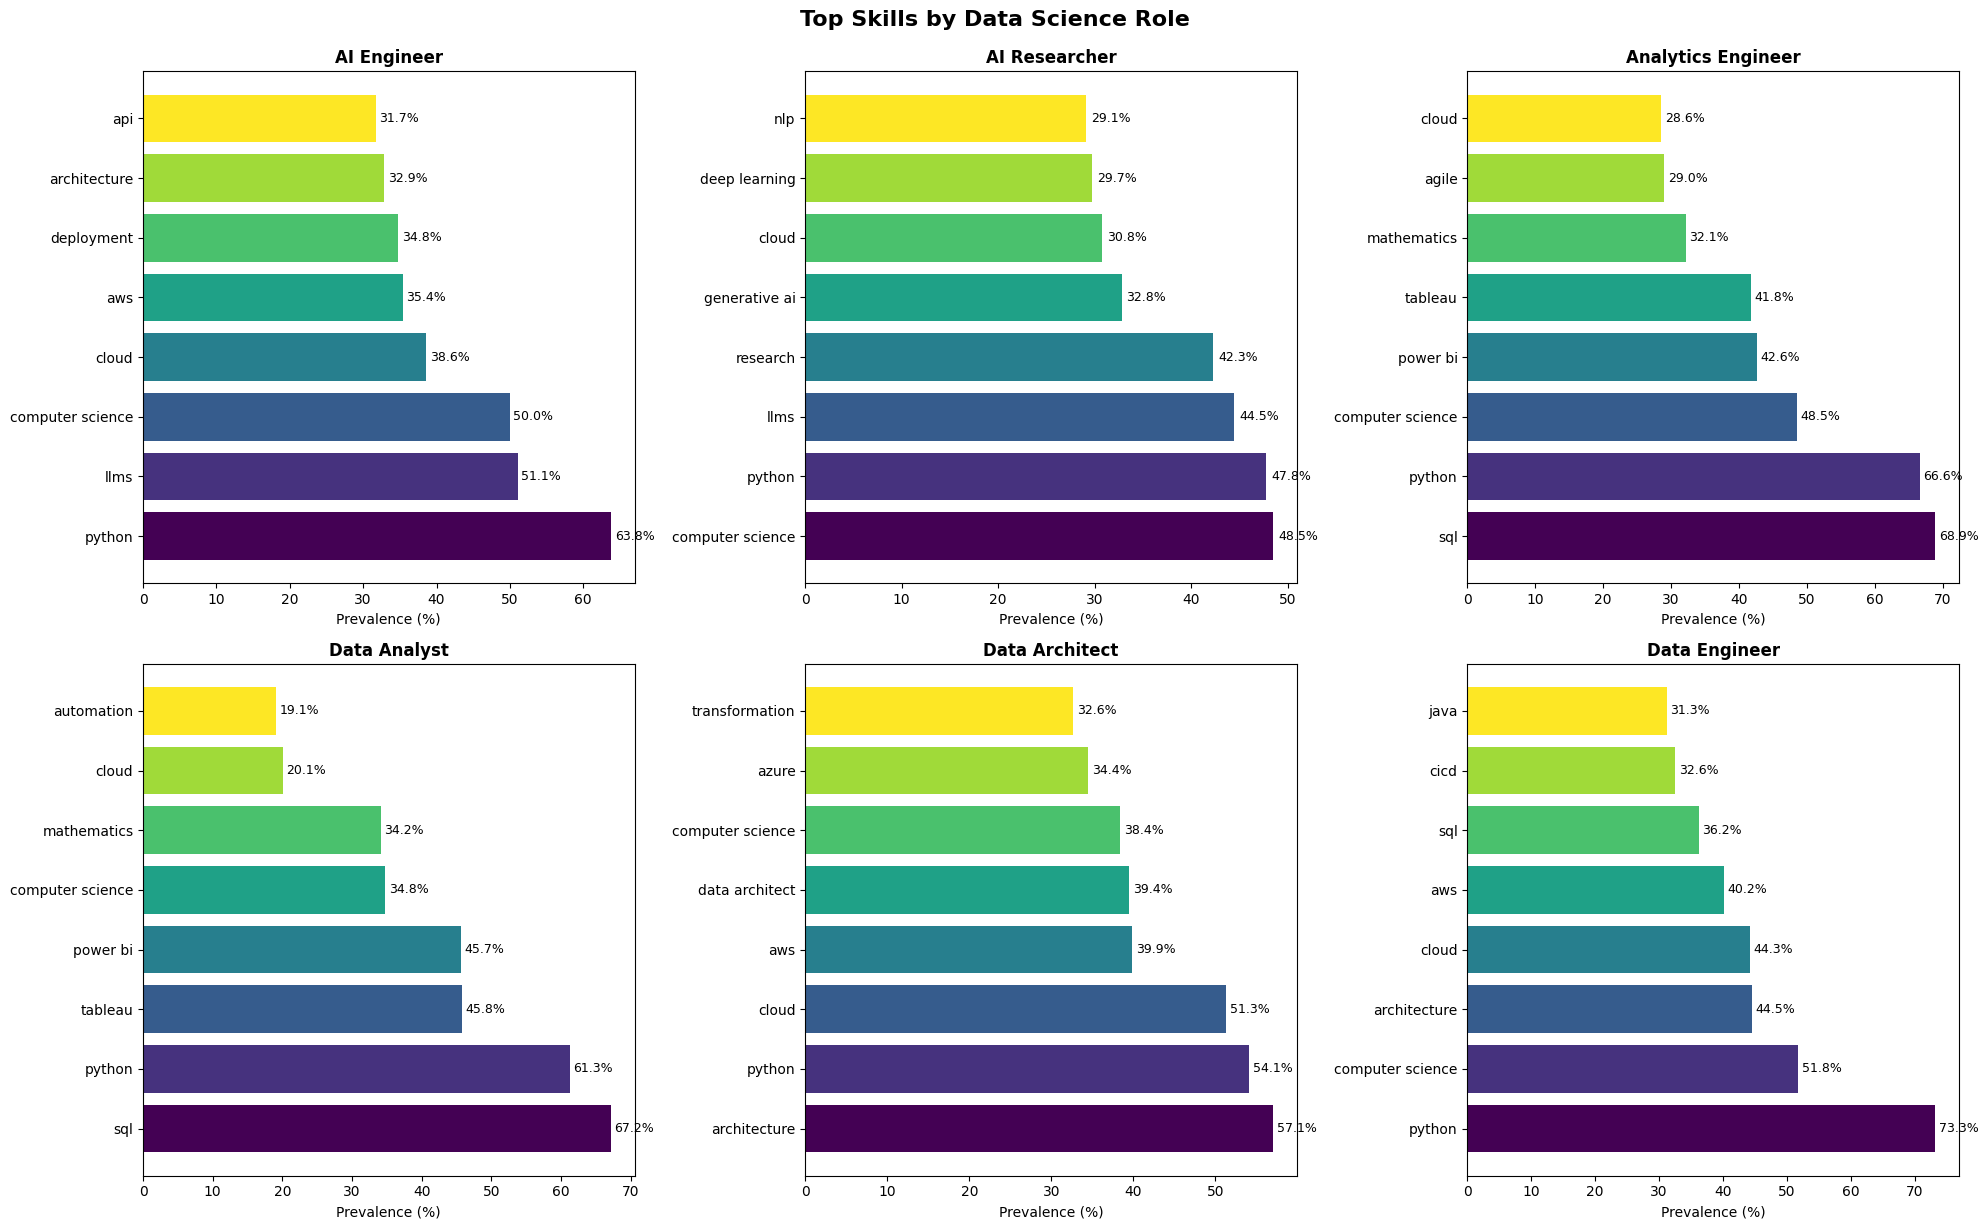

In [9]:
# Analyze skills for different data roles
role_skills = analyzer.analyze_skills_by_role(pivot_df, top_n=12)

print("🎭 SKILL PROFILES BY JOB ROLE")
print("="*40)

# Visualize top roles
top_roles = list(role_skills.keys())[:6]  # Show first 6 roles

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, role in enumerate(top_roles):
    if idx < 6:
        ax = axes[idx]
        role_data = role_skills[role].head(8)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(role_data)))
        ax.barh(role_data['skill'], role_data['prevalence'], color=colors)
        ax.set_title(f'{role}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(role_data['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Data Science Role', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 4.2 Role Comparison Matrix

🔄 ROLE SKILL PROFILE COMPARISON


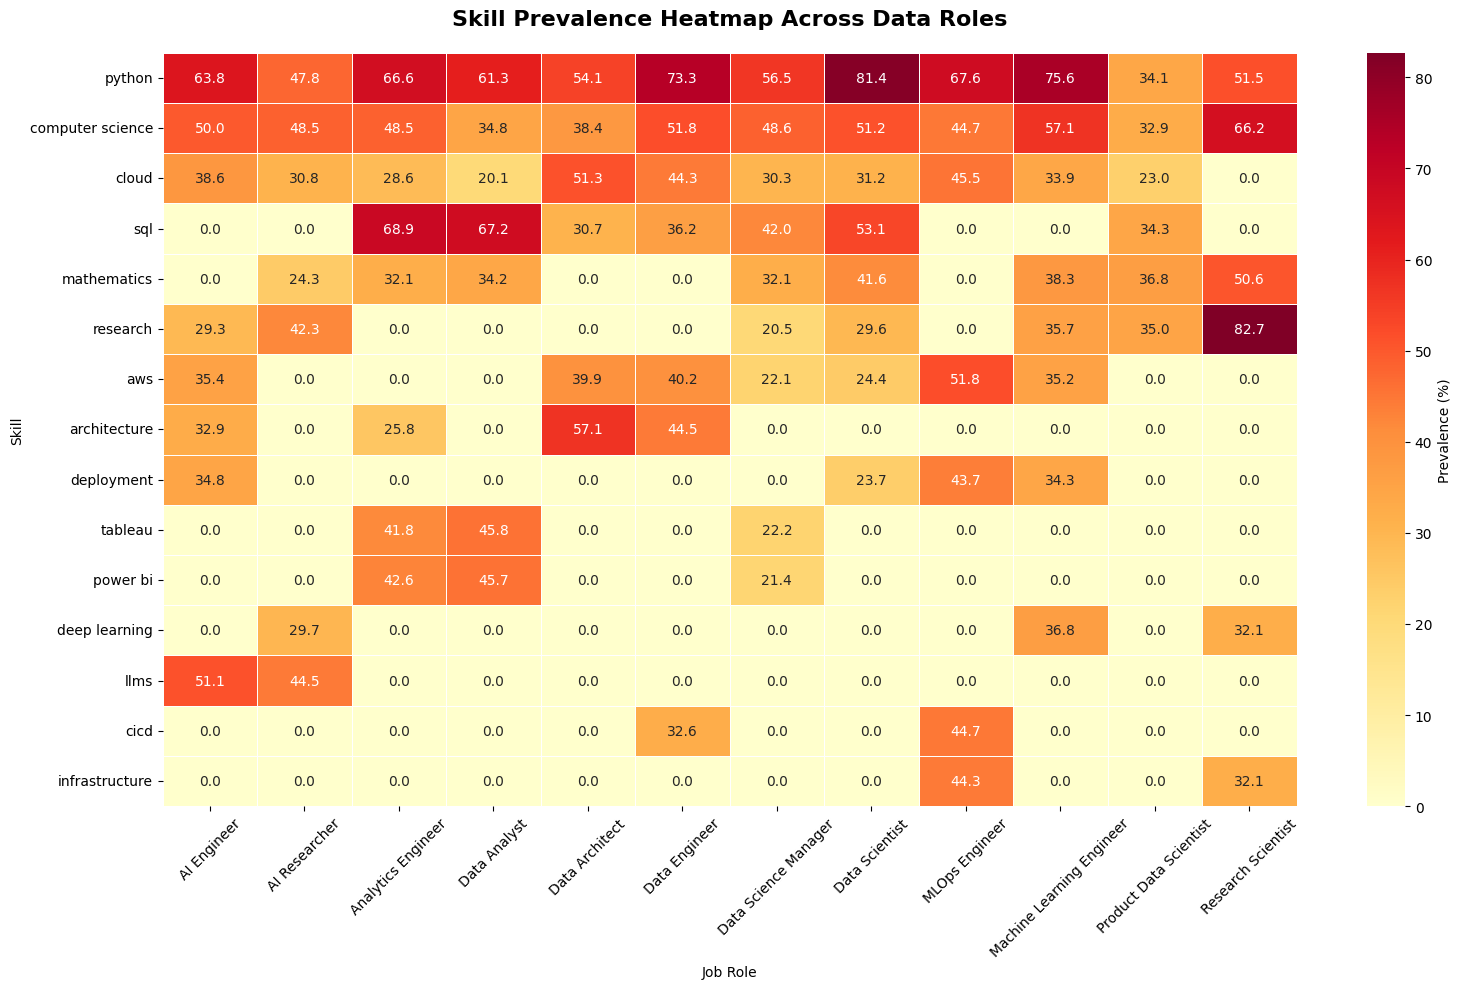


💡 Key Observations:
• Roles with distinct skill profiles are clearly visible
• Universal skills appear across multiple roles
• Role-specific specializations are evident


In [10]:
# Compare skill profiles across roles
print("🔄 ROLE SKILL PROFILE COMPARISON")
print("="*45)

role_comparison = analyzer.compare_role_skill_profiles(pivot_df)

# Create heatmap for role comparison
plt.figure(figsize=(16, 10))

# Select top skills for visualization
top_skills_comparison = role_comparison.mean(axis=1).nlargest(15).index
comparison_vis = role_comparison.loc[top_skills_comparison]

# Create heatmap
sns.heatmap(comparison_vis, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Prevalence (%)'})
plt.title('Skill Prevalence Heatmap Across Data Roles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Role')
plt.ylabel('Skill')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("• Roles with distinct skill profiles are clearly visible")
print("• Universal skills appear across multiple roles")
print("• Role-specific specializations are evident")

## 5. Enhanced Skill Trend Analysis Execution


In [11]:
# Run the enhanced analysis with mentions integration
print("Running enhanced skill trend analysis with mentions integration...")
results = analyzer.analyze_skill_trends_enhanced(
    pivot_df, 
    min_prevalence=1.0, 
    min_avg_mentions=5,
    min_months=8,
    smoothing_alpha=0.3
)

print(f"Analysis complete! Found {len(results)} skills meeting criteria")
print("\nTop 10 skills by volume-adjusted score:")
display(results.head(10)[['skill', 'volume_adjusted_score', 'trend_category', 'current_prevalence', 'avg_mentions_per_month']])

Running enhanced skill trend analysis with mentions integration...
Analysis complete! Found 176 skills meeting criteria

Top 10 skills by volume-adjusted score:


,skill,volume_adjusted_score,trend_category,current_prevalence,avg_mentions_per_month
0,json,513.545497,Accelerating,21.806451,126.48
1,prompt engineering,511.496173,Accelerating,12.536230,81.00
2,vector database,491.800853,Emerging,5.141057,31.80
3,http,486.735923,Stable,2.862633,21.36
4,llms,486.057073,Accelerating,29.405218,194.80
5,information retrieval,471.513048,Stabilizing,1.936577,14.32
6,ruby on rails,471.022866,Stable,1.995000,13.84
7,embeddings,461.436963,Growing,5.247140,33.08
8,langchain,440.903088,Emerging,6.924482,44.64
9,oracle,413.168061,Emerging,4.812097,35.56


### 5.1 Plot Trend Categories Distribution


Plotting trend categories distribution...


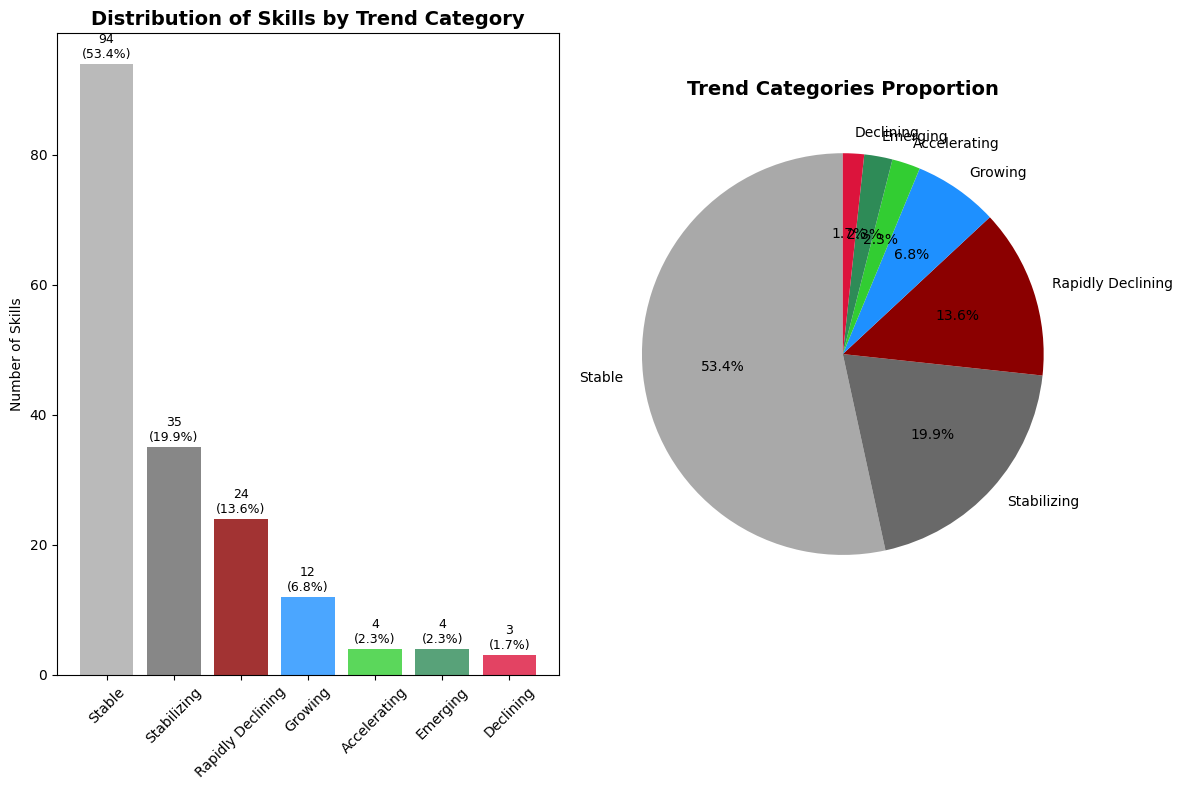

In [12]:
# Plot 1: Trend Categories Distribution
print("Plotting trend categories distribution...")
fig1 = analyzer.plot_trend_categories_distribution(results, figsize=(12, 8))
plt.show()

### 5.2 Plot Scatter Matrix of Key Metrics

Plotting scatter matrix of key metrics...


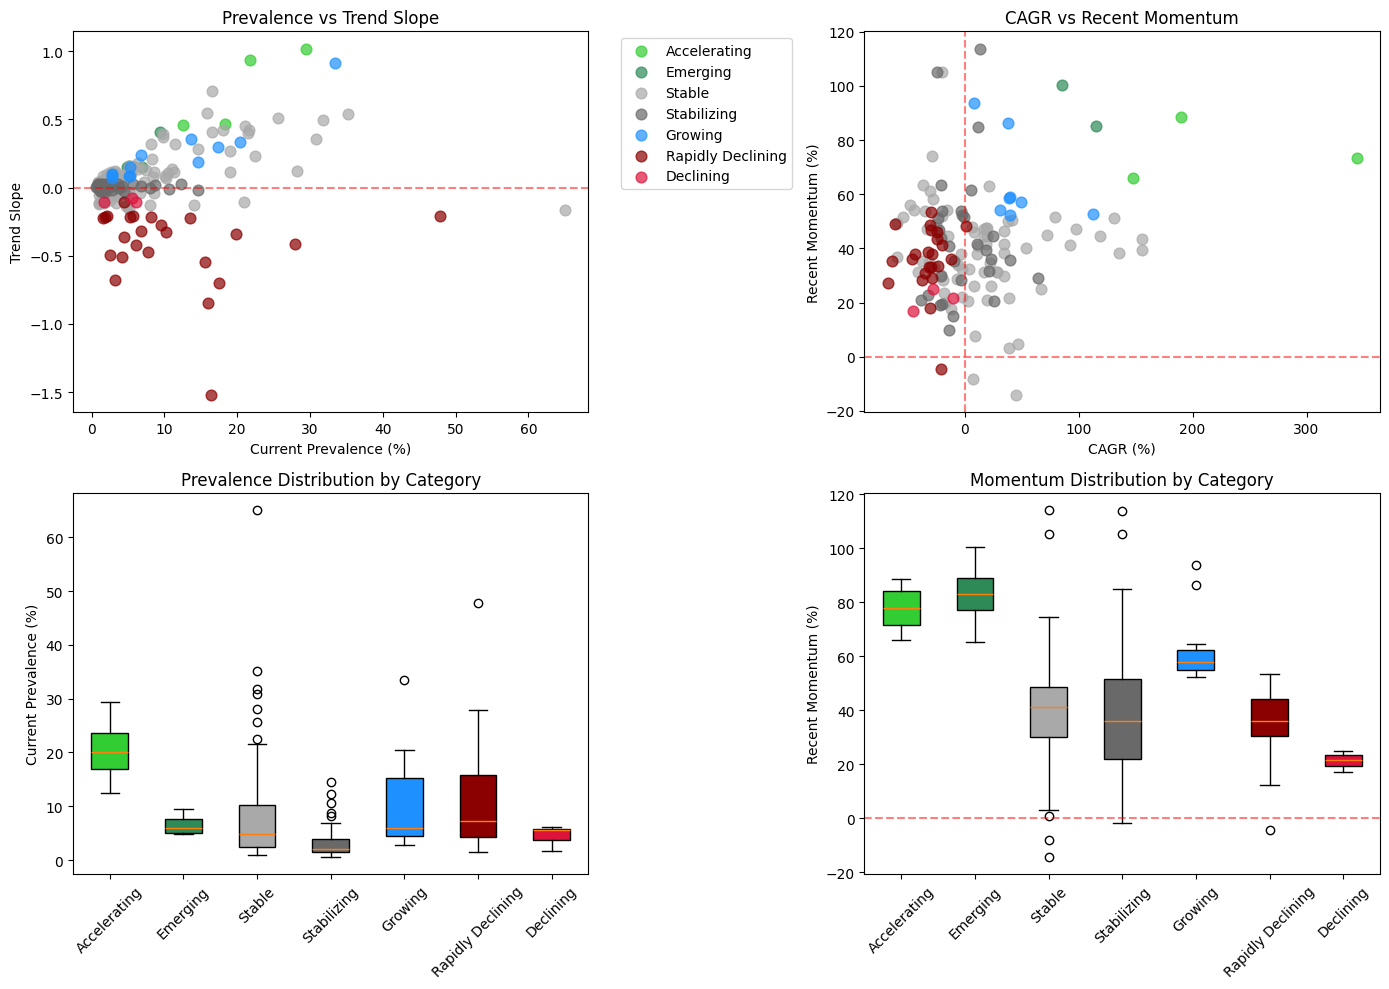

In [13]:
# Plot 2: Scatter Matrix of Key Metrics
print("Plotting scatter matrix of key metrics...")
fig2 = analyzer.plot_trend_scatter_matrix(results, figsize=(14, 10))
plt.show()

### 5.3  Plot Emerging vs Declining Skills

Plotting emerging vs declining skills...


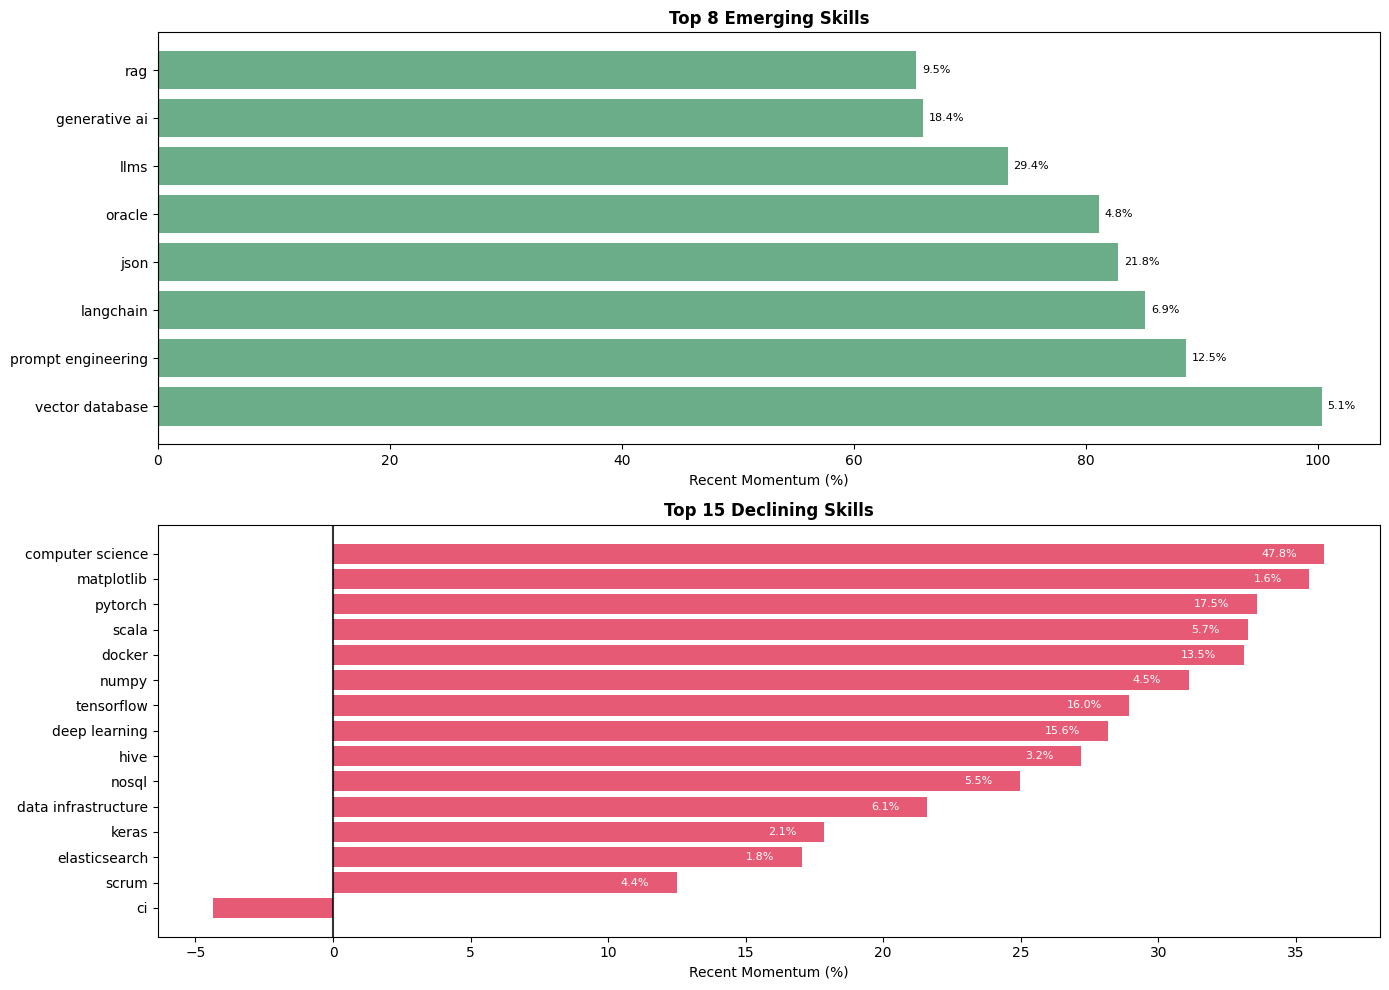

In [14]:
# Plot 3: Emerging vs Declining Skills
print("Plotting emerging vs declining skills...")
fig3 = analyzer.plot_emerging_vs_declining_skills(results, top_n=15, figsize=(14, 10))
plt.show()

### 5.4  Plot Skill Trend Timelines

Plotting timelines for skills: ['json', 'prompt engineering', 'vector database', 'ci', 'scrum', 'elasticsearch', 'json', 'prompt engineering']


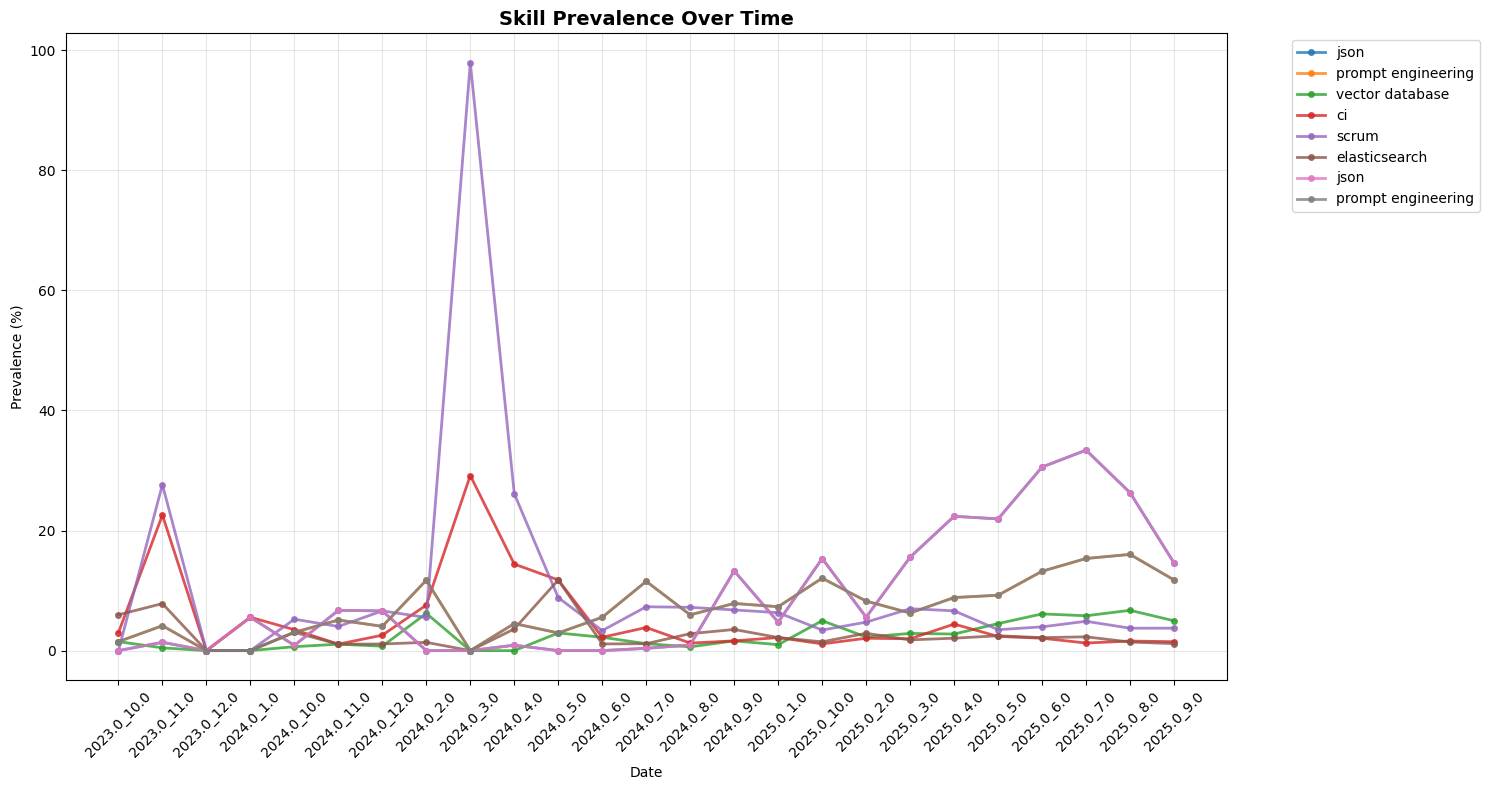

In [15]:
# Plot 4: Skill Trend Timelines
if not results.empty:
    # Get top emerging and declining skills for timeline plotting
    top_emerging = results[results['is_emerging']].nlargest(3, 'volume_adjusted_score')
    top_declining = results[results['is_declining']].nsmallest(3, 'volume_adjusted_score')
    top_growing = results[results['is_growing']].nlargest(2, 'volume_adjusted_score')
    
    skills_to_plot = list(top_emerging['skill']) + list(top_declining['skill']) + list(top_growing['skill'])
    
    print(f"Plotting timelines for skills: {skills_to_plot}")
    fig4 = analyzer.plot_skill_trend_timeline(pivot_df, skills_to_plot, figsize=(15, 8))
    plt.show()

### 5.5 High-Confidence Trends Analysis


=== HIGH-CONFIDENCE TRENDS ANALYSIS ===
Found 71 high-confidence trends (min 10 avg mentions per month)
Plotting high-confidence emerging vs declining skills...


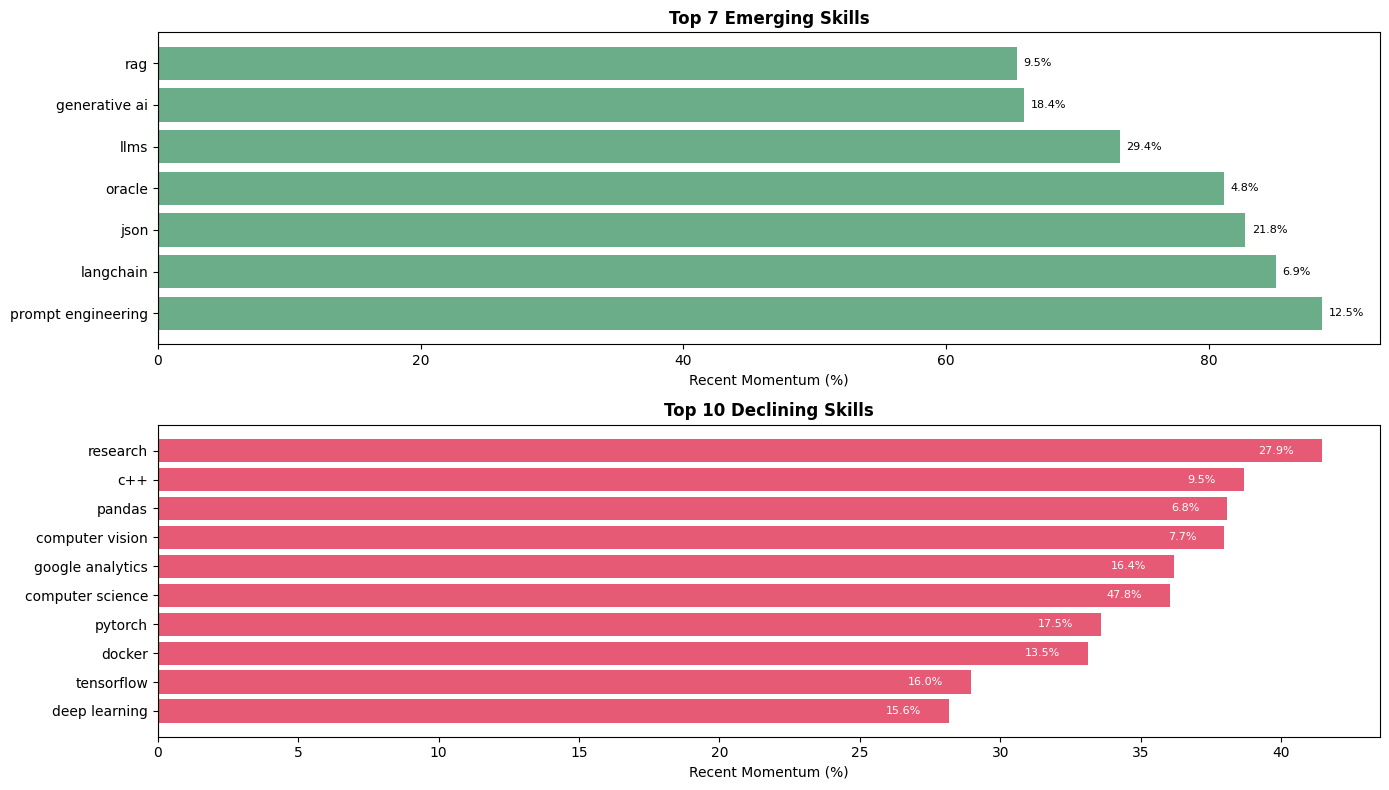

In [16]:
# Additional analysis: High-confidence trends
print("\n=== HIGH-CONFIDENCE TRENDS ANALYSIS ===")
high_confidence_trends = analyzer.get_high_confidence_trends(results, min_avg_mentions=10)
print(f"Found {len(high_confidence_trends)} high-confidence trends (min 10 avg mentions per month)")

# Plot high-confidence emerging vs declining
if not high_confidence_trends.empty:
    print("Plotting high-confidence emerging vs declining skills...")
    fig5 = analyzer.plot_emerging_vs_declining_skills(high_confidence_trends, top_n=10, figsize=(14, 8))
    plt.show()

### 5.6 Trend Category Summary Analysis

In [17]:
# Analyze results by trend category
print("\n=== TREND CATEGORY SUMMARY ===")
category_summary = results.groupby('trend_category').agg({
    'skill': 'count',
    'current_prevalence': 'mean',
    'volume_adjusted_score': 'mean',
    'avg_mentions_per_month': 'mean',
    'total_mentions': 'mean'
}).round(2)

category_summary = category_summary.rename(columns={'skill': 'skill_count'})
display(category_summary)


=== TREND CATEGORY SUMMARY ===


,skill_count,current_prevalence,volume_adjusted_score,avg_mentions_per_month,total_mentions
trend_category,,,,,
Accelerating,4,20.53,479.95,131.95,3298.75
Declining,3,4.45,97.18,31.97,799.33
Emerging,4,6.58,426.72,43.53,1088.25
Growing,12,10.84,328.45,73.75,1843.67
Rapidly Declining,24,10.77,186.73,79.18,1979.38
Stabilizing,35,3.54,167.71,25.87,646.69
Stable,94,8.45,190.63,60.54,1513.38


### 5.7 Traditional vs Enhanced Ranking Comparison

In [18]:
# Compare traditional vs enhanced ranking
print("\n=== COMPARISON: TRADITIONAL vs ENHANCED RANKING ===")
traditional_top = results.nlargest(10, 'recent_momentum_pct')[['skill', 'recent_momentum_pct', 'current_prevalence', 'avg_mentions_per_month', 'trend_category']]
enhanced_top = results.nlargest(10, 'volume_adjusted_score')[['skill', 'volume_adjusted_score', 'current_prevalence', 'avg_mentions_per_month', 'trend_category']]

print("Traditional Top 10 (by momentum only):")
display(traditional_top)
print("\nEnhanced Top 10 (by volume-adjusted score):")
display(enhanced_top)


=== COMPARISON: TRADITIONAL vs ENHANCED RANKING ===
Traditional Top 10 (by momentum only):


,skill,recent_momentum_pct,current_prevalence,avg_mentions_per_month,trend_category
6,ruby on rails,114.019735,1.995000,13.84,Stable
5,information retrieval,113.794994,1.936577,14.32,Stabilizing
11,applied ml,105.171634,1.722401,11.64,Stabilizing
3,http,105.144434,2.862633,21.36,Stable
2,vector database,100.337395,5.141057,31.80,Emerging
7,embeddings,93.836339,5.247140,33.08,Growing
1,prompt engineering,88.605945,12.536230,81.00,Accelerating
14,product design,86.441433,2.838234,18.92,Growing
8,langchain,85.132379,6.924482,44.64,Emerging
18,prometheus,84.841988,1.866765,12.32,Stabilizing



Enhanced Top 10 (by volume-adjusted score):


,skill,volume_adjusted_score,current_prevalence,avg_mentions_per_month,trend_category
0,json,513.545497,21.806451,126.48,Accelerating
1,prompt engineering,511.496173,12.536230,81.00,Accelerating
2,vector database,491.800853,5.141057,31.80,Emerging
3,http,486.735923,2.862633,21.36,Stable
4,llms,486.057073,29.405218,194.80,Accelerating
5,information retrieval,471.513048,1.936577,14.32,Stabilizing
6,ruby on rails,471.022866,1.995000,13.84,Stable
7,embeddings,461.436963,5.247140,33.08,Growing
8,langchain,440.903088,6.924482,44.64,Emerging
9,oracle,413.168061,4.812097,35.56,Emerging


### 5.8 Category-Specific Timeline Analysis

Plotting timelines for accelerating skills: ['json', 'prompt engineering', 'llms']


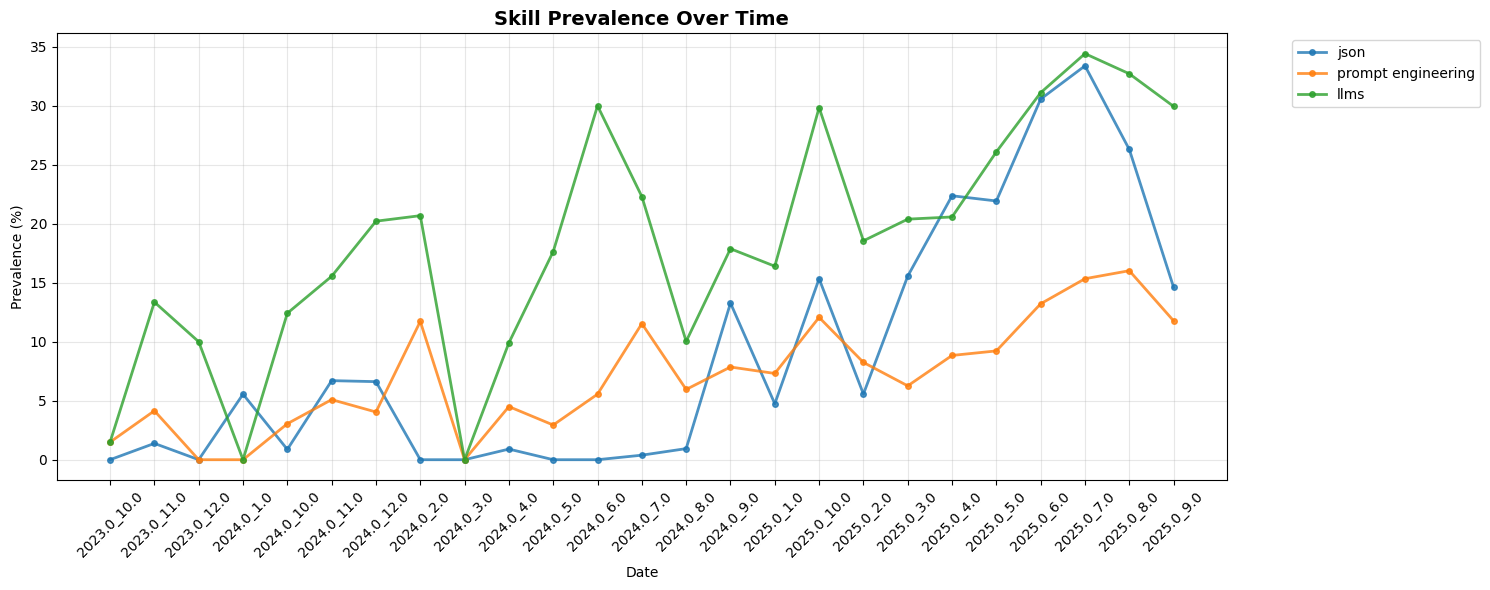

In [19]:
# Plot additional timelines for specific categories
if not results.empty:
    # Plot timelines for top accelerating skills
    accelerating_skills = results[results['trend_category'] == 'Accelerating']
    if not accelerating_skills.empty:
        top_accelerating = accelerating_skills.nlargest(3, 'volume_adjusted_score')
        print(f"Plotting timelines for accelerating skills: {list(top_accelerating['skill'])}")
        fig6 = analyzer.plot_skill_trend_timeline(pivot_df, list(top_accelerating['skill']), figsize=(15, 6))
        plt.show()
    
    # Plot timelines for peaking skills
    peaking_skills = results[results['trend_category'] == 'Peaking']
    if not peaking_skills.empty:
        top_peaking = peaking_skills.nlargest(3, 'current_prevalence')
        print(f"Plotting timelines for peaking skills: {list(top_peaking['skill'])}")
        fig7 = analyzer.plot_skill_trend_timeline(pivot_df, list(top_peaking['skill']), figsize=(15, 6))
        plt.show()

### 5.9 Final Summary Report

In [20]:
# Final summary report
print("\n=== FINAL SUMMARY REPORT ===")
print(f"Total skills analyzed: {len(results)}")
print(f"Emerging skills: {results['is_emerging'].sum()}")
print(f"Declining skills: {results['is_declining'].sum()}")
print(f"Growing skills: {results['is_growing'].sum()}")
print(f"Stable skills: {results['is_stable'].sum()}")
print(f"Special case skills: {results['is_special'].sum()}")

# Average metrics
print(f"\nAverage current prevalence: {results['current_prevalence'].mean():.2f}%")
print(f"Average monthly mentions: {results['avg_mentions_per_month'].mean():.2f}")
print(f"Average volume-adjusted score: {results['volume_adjusted_score'].mean():.2f}")


=== FINAL SUMMARY REPORT ===
Total skills analyzed: 176
Emerging skills: 8
Declining skills: 27
Growing skills: 16
Stable skills: 129
Special case skills: 0

Average current prevalence: 8.12%
Average monthly mentions: 57.83
Average volume-adjusted score: 205.29


## 6. Skill Ecosystem Analysis
### 6.1 Skill Combinations and Clusters

INFO:src.analyze_jobs:🔗 Ultra-fast Skill Combination Prevalence Analysis...
INFO:src.analyze_jobs:🔗 Fast skill combination analysis...


🔗 SKILL COMBINATIONS AND NATURAL CLUSTERS


Counting combinations: 100%|██████████| 17954/17954 [00:01<00:00, 17394.38it/s]
INFO:src.analyze_jobs:📊 Pre-computing helper data...
Pre-computing skill job sets: 100%|██████████| 20/20 [00:00<00:00, 22.99it/s]
INFO:src.analyze_jobs:🎯 Pre-computing role skill rankings...
Processing combinations: 100%|██████████| 30/30 [00:00<00:00, 227.59it/s]


🤝 TOP SKILL COMBINATIONS
------------------------------


,skill_1,skill_2,prevalence,combination_type,learning_synergy
0,computer science,python,24.33%,Cross-Domain: Other + Programming,Very High Synergy
1,python,sql,19.45%,Same Domain: Programming,High Synergy
2,mathematics,python,15.71%,Cross-Domain: Other + Programming,High Synergy
3,cloud,python,15.57%,Cross-Domain: Other + Programming,High Synergy
4,computer science,mathematics,13.78%,Same Domain: Other,High Synergy
5,python,research,12.80%,Cross-Domain: Programming + Other,Medium Synergy
6,json,mathematics,12.71%,Same Domain: Other,Very High Synergy
7,aws,python,12.55%,Cross-Domain: Cloud + Programming,High Synergy
8,computer science,research,11.44%,Same Domain: Other,Medium Synergy
9,computer science,sql,11.12%,Cross-Domain: Other + Programming,Medium Synergy


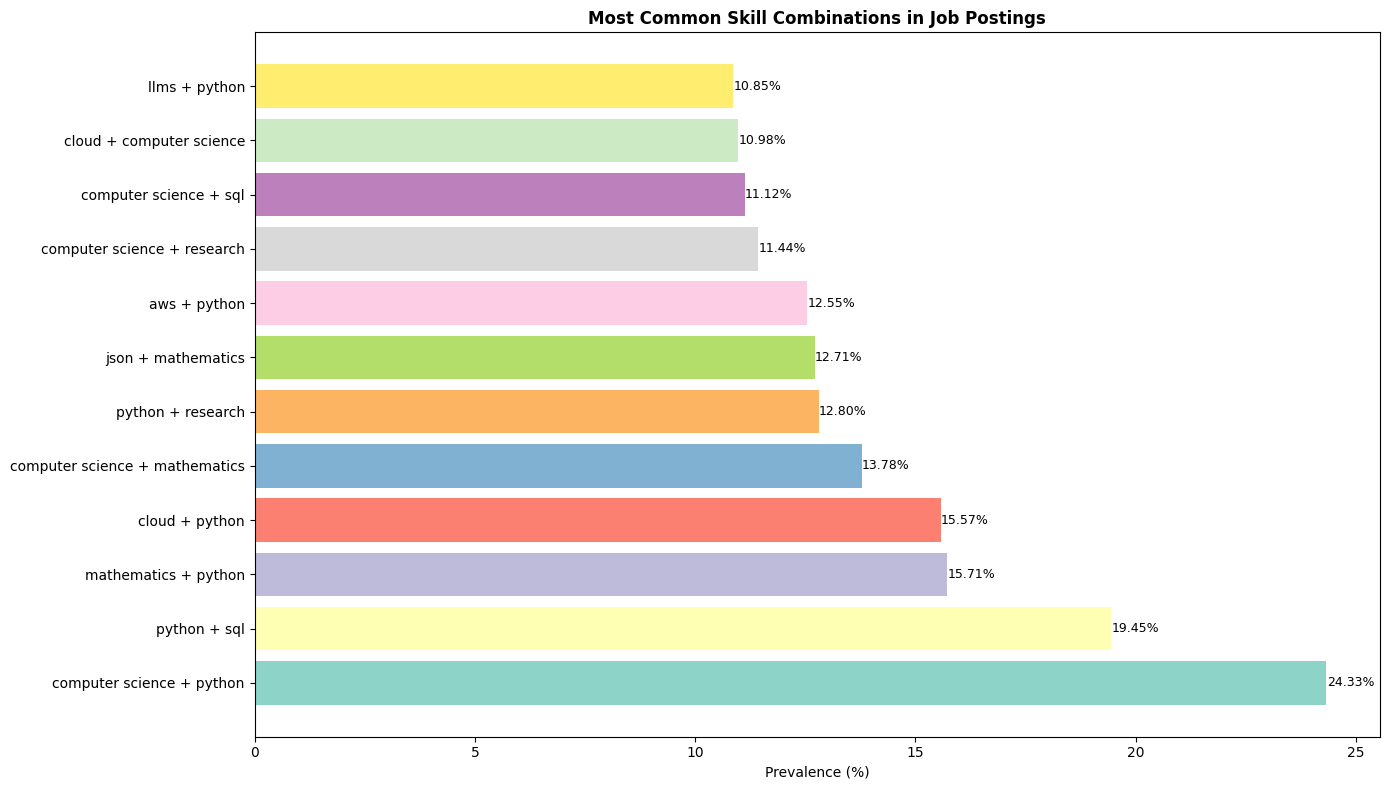

In [21]:
# Analyze skill combinations and natural clusters
print("🔗 SKILL COMBINATIONS AND NATURAL CLUSTERS")
print("="*55)

# Analyze common skill combinations
skill_combinations = analyzer.analyze_skill_combination_prevalence(pivot_df, top_n=15)

if not skill_combinations.empty:
    print("\n🤝 TOP SKILL COMBINATIONS")
    print("-" * 30)
    
    # Display combination table
    combo_display = skill_combinations[['skill_1', 'skill_2', 'prevalence', 'combination_type', 'learning_synergy']]
    display(combo_display.head(10).style.background_gradient(cmap='Purples', subset=['prevalence'])
           .format({'prevalence': '{:.2f}%'}))
    
    # Visualize combinations
    plt.figure(figsize=(14, 8))
    top_combos = skill_combinations.head(12)
    
    # Create combination labels
    combo_labels = [f"{row['skill_1']} + {row['skill_2']}" for _, row in top_combos.iterrows()]
    
    plt.barh(combo_labels, top_combos['prevalence'], 
             color=plt.cm.Set3(np.linspace(0, 1, len(top_combos))))
    plt.xlabel('Prevalence (%)')
    plt.title('Most Common Skill Combinations in Job Postings', fontweight='bold')
    
    for i, v in enumerate(top_combos['prevalence']):
        plt.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

### 6.2 Natural Skill Clusters

INFO:src.analyze_jobs:🎯 Fast Natural Skill Clusters Identification...



🎯 NATURAL SKILL CLUSTERS
------------------------------


Building clusters: 100%|██████████| 30/30 [00:00<00:00, 34.73it/s]


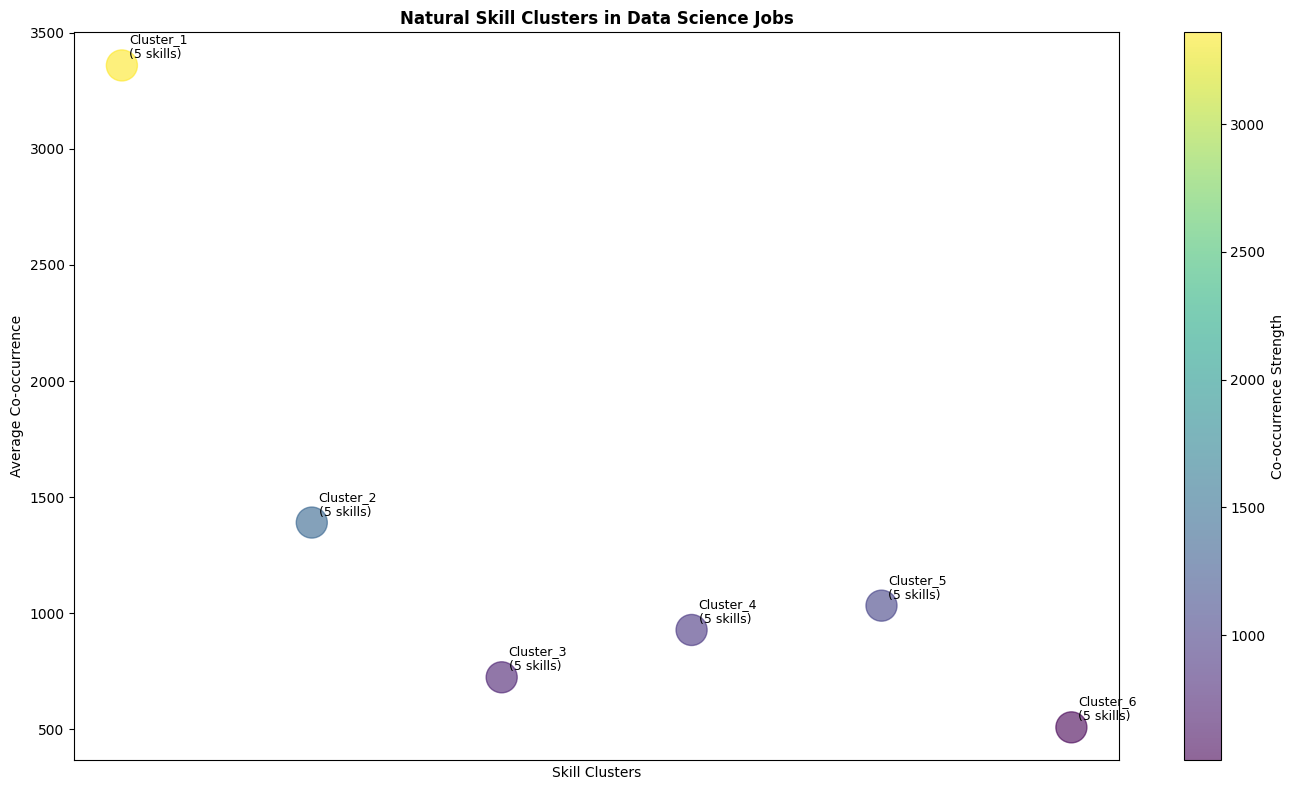


🔍 Cluster Details:

   Cluster_1:
      Core skill: aws
      Skills: aws, python, cloud, azure
      Avg co-occurrence: 3359.2

   Cluster_2:
      Core skill: testing
      Skills: testing, computer science, sql, deployment
      Avg co-occurrence: 1391.0

   Cluster_3:
      Core skill: transformation
      Skills: transformation, automation, agile, security
      Avg co-occurrence: 724.8

   Cluster_4:
      Core skill: cicd
      Skills: cicd, api, infrastructure, java
      Avg co-occurrence: 928.5

   Cluster_5:
      Core skill: nlp
      Skills: nlp, deep learning, pytorch, tensorflow
      Avg co-occurrence: 1033.2

   Cluster_6:
      Core skill: json
      Skills: json, product management, ios, generative ai
      Avg co-occurrence: 509.2


In [22]:
# Identify natural skill clusters
print("\n🎯 NATURAL SKILL CLUSTERS")
print("-" * 30)

skill_clusters = analyzer.identify_natural_skill_clusters(pivot_df)

if skill_clusters:
    # Visualize clusters
    fig, ax = plt.subplots(figsize=(14, 8))
    
    cluster_names = list(skill_clusters.keys())
    cluster_sizes = [len(cluster['skills']) for cluster in skill_clusters.values()]
    cluster_co_occurrence = [cluster['avg_co_occurrence'] for cluster in skill_clusters.values()]
    
    # Create bubble chart
    scatter = ax.scatter(range(len(cluster_names)), cluster_co_occurrence, 
                        s=[size*100 for size in cluster_sizes], alpha=0.6, 
                        c=cluster_co_occurrence, cmap='viridis')
    
    # Add labels
    for i, (name, size) in enumerate(zip(cluster_names, cluster_sizes)):
        ax.annotate(f"{name}\n({size} skills)", 
                   (i, cluster_co_occurrence[i]), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, ha='left')
    
    ax.set_xlabel('Skill Clusters')
    ax.set_ylabel('Average Co-occurrence')
    ax.set_title('Natural Skill Clusters in Data Science Jobs', fontweight='bold')
    plt.colorbar(scatter, label='Co-occurrence Strength')
    plt.xticks([])
    plt.tight_layout()
    plt.show()
    
    # Print cluster details
    print("\n🔍 Cluster Details:")
    for cluster_name, cluster_data in list(skill_clusters.items())[:6]:
        print(f"\n   {cluster_name}:")
        print(f"      Core skill: {cluster_data['core_skill']}")
        print(f"      Skills: {', '.join(cluster_data['skills'][:4])}")
        print(f"      Avg co-occurrence: {cluster_data['avg_co_occurrence']:.1f}")

## 7. Regional and Company Analysis
### 7.1 Regional Skill Demand 

🌍 REGIONAL SKILL DEMAND VARIATIONS


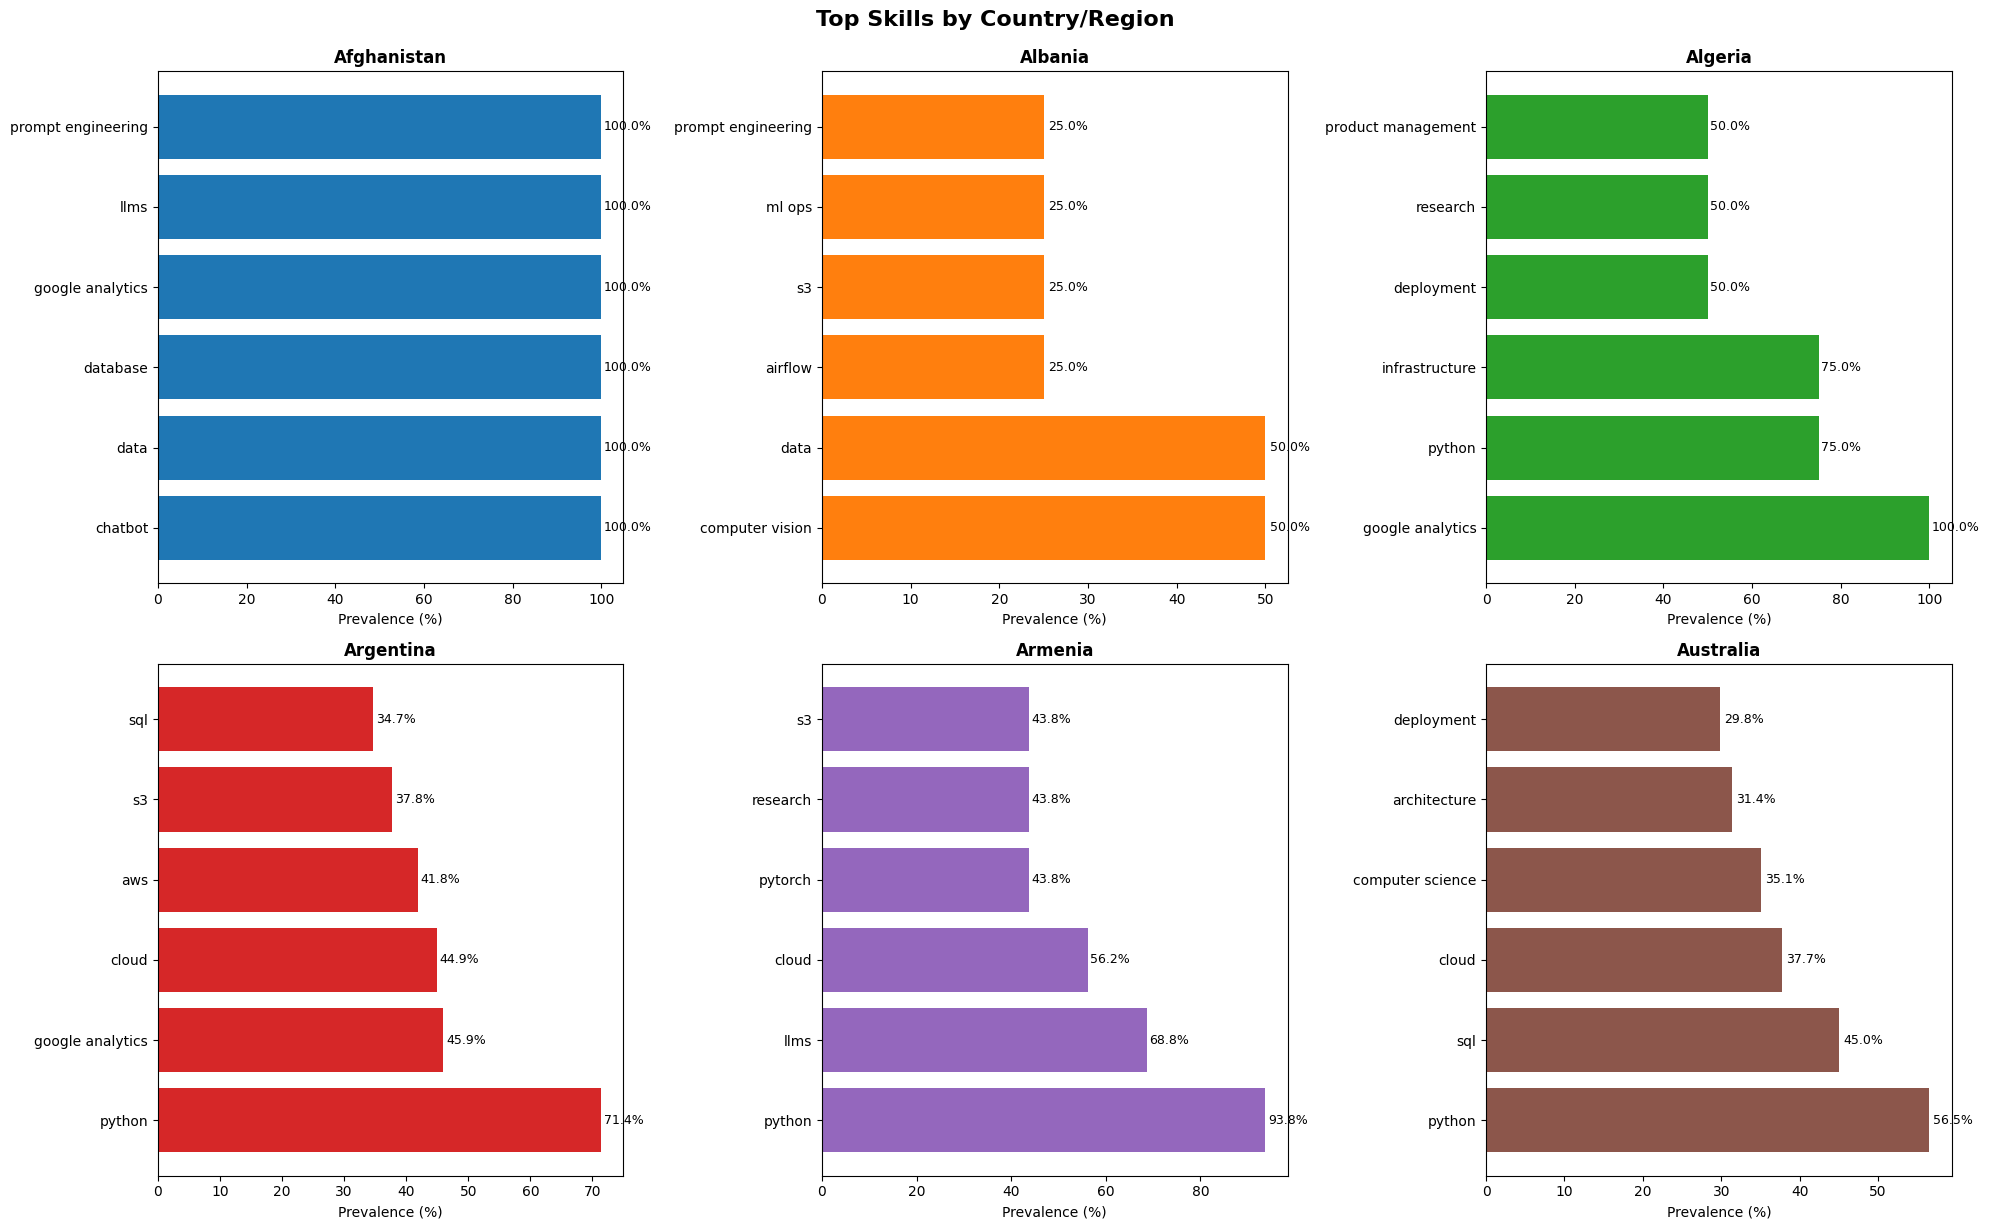

💡 Regional Insights:
   • Afghanistan: chatbot (100.0%)
   • Albania: computer vision (50.0%)
   • Algeria: google analytics (100.0%)


In [23]:
# Analyze regional variations in skill demand
print("🌍 REGIONAL SKILL DEMAND VARIATIONS")
print("="*45)

regional_skills = analyzer.analyze_regional_skill_demand(pivot_df, top_n=8)

if regional_skills:
    # Plot top countries
    top_countries = list(regional_skills.keys())[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, country in enumerate(top_countries):
        if idx < 6:
            ax = axes[idx]
            country_data = regional_skills[country].head(6)
            
            ax.barh(country_data['skill'], country_data['prevalence'], 
                   color=plt.cm.tab10(idx))
            ax.set_title(f'{country}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Prevalence (%)')
            
            for i, v in enumerate(country_data['prevalence']):
                ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.suptitle('Top Skills by Country/Region', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    print("💡 Regional Insights:")
    for country in top_countries[:3]:
        top_skill = regional_skills[country].iloc[0]['skill']
        prevalence = regional_skills[country].iloc[0]['prevalence']
        print(f"   • {country}: {top_skill} ({prevalence:.1f}%)")